In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torchvision import models, transforms

print("PyTorch version:", torch.__version__)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

PyTorch version: 2.14.0+cpu
Device: cpu


In [3]:
project_root = Path.cwd().parent

if not (project_root / "data").exists():
    project_root = Path.cwd().parent.parent

processed_dir = project_root / "data" / "processed"

clean_metadata_path = (
    processed_dir / "agrisense_metadata_clean.csv"
)

df_clean = pd.read_csv(clean_metadata_path)

print("Shape:", df_clean.shape)
print("Project root:", project_root)

Shape: (7399, 11)
Project root: c:\Users\Dell\Documents\Projects\AgriSense


In [4]:
# Disease Mapping

disease_classes = sorted(df_clean["Disease"].unique())

disease_to_id = {
    disease: idx
    for idx, disease in enumerate(disease_classes)
}

id_to_disease = {
    idx: disease
    for disease, idx in disease_to_id.items()
}

df_clean["disease_id"] = df_clean["Disease"].map(disease_to_id)

print("Disease classes:", len(disease_classes))
print("Missing disease IDs:", df_clean["disease_id"].isna().sum())

Disease classes: 115
Missing disease IDs: 0


In [5]:
# Model configuration (Recreating the fine-tuned ResNet-18)
num_classes = len(disease_classes)

weights = models.ResNet18_Weights.DEFAULT

model = models.resnet18(weights=weights)

model.fc = nn.Linear(
    model.fc.in_features,
    num_classes
)

model = model.to(
    torch.device("cuda" if torch.cuda.is_available() else "cpu")
)

device = next(model.parameters()).device

print("Device:", device)
print("Number of classes:", num_classes)

Device: cpu
Number of classes: 115


In [6]:
# Loading best Checkpoint

checkpoint_dir = (
    project_root / "models" / "checkpoints"
)

best_checkpoint_path = (
    checkpoint_dir / "resnet18_finetuned_best.pth"
)

print("Checkpoint exists:", best_checkpoint_path.exists())
print("Checkpoint path:", best_checkpoint_path)

Checkpoint exists: True
Checkpoint path: c:\Users\Dell\Documents\Projects\AgriSense\models\checkpoints\resnet18_finetuned_best.pth


In [7]:
checkpoint = torch.load(
    best_checkpoint_path,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("Fine-tuned checkpoint loaded.")
print("Checkpoint epoch:", checkpoint["epoch"])
print("Validation loss:", checkpoint["val_loss"])
print("Validation accuracy:", checkpoint["val_accuracy"])
print("Validation Macro F1:", checkpoint["val_macro_f1"])

Fine-tuned checkpoint loaded.
Checkpoint epoch: 5
Validation loss: 1.5560793709078788
Validation accuracy: 0.5684340320591862
Validation Macro F1: 0.4176858941901695


In [8]:
# recreating Image Lookup

image_root = (
    project_root
    / "data"
    / "raw"
    / "PlantSeg"
    / "images"
)

image_files = list(
    image_root.rglob("*")
)

image_lookup = {
    path.name: path
    for path in image_files
    if path.is_file()
}

df_clean["actual_image_path"] = (
    df_clean["Name"].map(image_lookup)
)

print(
    "Missing image paths:",
    df_clean["actual_image_path"].isna().sum()
)

Missing image paths: 0


In [9]:
# GradCam implementation

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        self.forward_handle = target_layer.register_forward_hook(
            self.save_activations
        )

        self.backward_handle = target_layer.register_full_backward_hook(
            self.save_gradients
        )

    def save_activations(self, module, input, output):
        self.activations = output

    def save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, image_tensor, class_index):

        self.model.zero_grad()

        output = self.model(image_tensor)

        target_score = output[:, class_index].sum()

        target_score.backward()

        gradients = self.gradients
        activations = self.activations

        # Global average pooling of gradients
        weights = gradients.mean(
            dim=(2, 3),
            keepdim=True
        )

        # Weighted combination of activation maps
        cam = (
            weights * activations
        ).sum(dim=1, keepdim=True)

        # Keep positive influence
        cam = torch.relu(cam)

        # Resize CAM to image dimensions
        cam = torch.nn.functional.interpolate(
            cam,
            size=image_tensor.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        # Normalize to 0-1
        cam = cam.squeeze()

        cam_min = cam.min()
        cam_max = cam.max()

        cam = (
            cam - cam_min
        ) / (
            cam_max - cam_min + 1e-8
        )

        return cam.detach().cpu().numpy(), output.detach()

In [10]:
# initialize GradCam

target_layer = model.layer4[-1]

grad_cam = GradCAM(
    model,
    target_layer
)

print("Grad-CAM target layer:")
print(target_layer)

Grad-CAM target layer:
BasicBlock(
  (conv1): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
)


In [11]:
#Select test samples
test_df = df_clean[df_clean["Split"] == "Test"].reset_index(drop=True)

#Select one sample
sample = test_df.iloc[0]

image = Image.open(sample["actual_image_path"]).convert("RGB")

print("Image:", sample["Name"])
print("True disease:", sample["Disease"])
print("Image size:", image.size)

Image: zucchini_yellow_mosaic_virus_66.jpg
True disease: zucchini yellow mosaic virus
Image size: (600, 350)


In [12]:
class ResizeWithPadding:
    def __init__(self, size):
        self.target_h, self.target_w = size

    def __call__(self, image):
        w, h = image.size

        scale = min(self.target_w / w, self.target_h / h)

        new_w = int(round(w * scale))
        new_h = int(round(h * scale))

        image = image.resize(
            (new_w, new_h),
            Image.Resampling.BILINEAR
        )

        canvas = Image.new(
            "RGB",
            (self.target_w, self.target_h),
            (0, 0, 0)
        )

        left = (self.target_w - new_w) // 2
        top = (self.target_h - new_h) // 2

        canvas.paste(image, (left, top))

        return canvas


classification_transform = transforms.Compose([
    ResizeWithPadding((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

input_tensor = classification_transform(image).unsqueeze(0).to(device)

print("Input tensor shape:", input_tensor.shape)
print("Device:", input_tensor.device)

Input tensor shape: torch.Size([1, 3, 224, 224])
Device: cpu


In [13]:
# Get model prediction
model.eval()

with torch.no_grad():
    logits = model(input_tensor)
    probabilities = torch.softmax(logits, dim=1)

predicted_id = probabilities.argmax(dim=1).item()
predicted_disease = id_to_disease[predicted_id]
confidence = probabilities[0, predicted_id].item()

true_disease = sample["Disease"]

print("True disease:", true_disease)
print("Predicted disease:", predicted_disease)
print(f"Confidence: {confidence:.4f}")

True disease: zucchini yellow mosaic virus
Predicted disease: zucchini yellow mosaic virus
Confidence: 0.2363


In [14]:
# Generate Grad-CAM for the predicted disease
cam, output = grad_cam.generate(
    input_tensor,
    predicted_id
)

print("Grad-CAM shape:", cam.shape)
print("Grad-CAM min:", cam.min())
print("Grad-CAM max:", cam.max())

Grad-CAM shape: (224, 224)
Grad-CAM min: 0.0
Grad-CAM max: 1.0


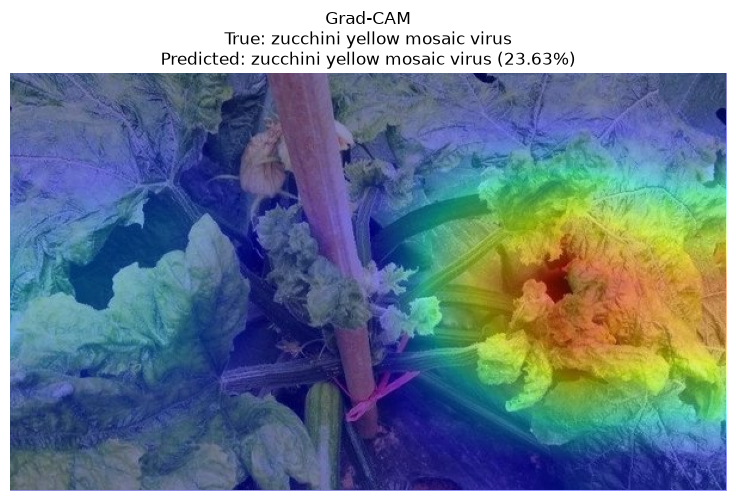

In [15]:
#Grad-CAM heatmap overlay

plt.figure(figsize=(8, 5))

plt.imshow(image)
plt.imshow(
    cam,
    cmap="jet",
    alpha=0.45,
    extent=(0, image.width, image.height, 0)
)

plt.title(
    f"Grad-CAM\n"
    f"True: {true_disease}\n"
    f"Predicted: {predicted_disease} ({confidence:.2%})"
)

plt.axis("off")
plt.tight_layout()
plt.show()

In [16]:
# Find the corresponding ground-truth mask
annotation_root = project_root / "data" / "raw" / "PlantSeg" / "annotations"

mask_files = list(annotation_root.rglob("*.png"))
mask_lookup = {path.name: path for path in mask_files}

mask_path = mask_lookup.get(sample["Label file"])

print("Mask path:", mask_path)
print("Mask exists:", mask_path is not None and mask_path.exists())

Mask path: c:\Users\Dell\Documents\Projects\AgriSense\data\raw\PlantSeg\annotations\test\zucchini_yellow_mosaic_virus_66.png
Mask exists: True


In [17]:
def resize_mask_with_padding(mask, size=(224, 224)):
    target_h, target_w = size

    w, h = mask.size

    scale = min(target_w / w, target_h / h)

    new_w = int(round(w * scale))
    new_h = int(round(h * scale))

    mask = mask.resize(
        (new_w, new_h),
        Image.Resampling.NEAREST
    )

    canvas = Image.new(
        "L",
        (target_w, target_h),
        0
    )

    left = (target_w - new_w) // 2
    top = (target_h - new_h) // 2

    canvas.paste(mask, (left, top))

    return canvas


ground_truth_mask = Image.open(mask_path).convert("L")

ground_truth_mask = resize_mask_with_padding(
    ground_truth_mask,
    (224, 224)
)

ground_truth_mask = np.array(ground_truth_mask)
ground_truth_mask = (ground_truth_mask > 0).astype(np.uint8)

print("Mask shape:", ground_truth_mask.shape)
print("Mask values:", np.unique(ground_truth_mask))
print("Mask coverage:", ground_truth_mask.mean())

Mask shape: (224, 224)
Mask values: [0 1]
Mask coverage: 0.40330038265306123


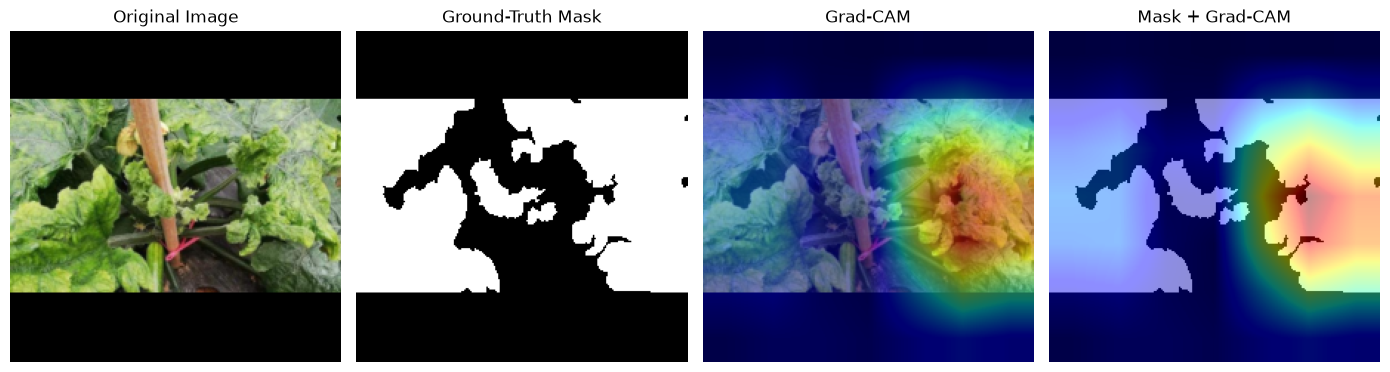

In [18]:
display_image = ResizeWithPadding((224, 224))(image)
display_image_np = np.array(display_image)

plt.figure(figsize=(14, 4))

plt.subplot(1, 4, 1)
plt.imshow(display_image_np)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(ground_truth_mask, cmap="gray")
plt.title("Ground-Truth Mask")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(display_image_np)
plt.imshow(cam, cmap="jet", alpha=0.45)
plt.title("Grad-CAM")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(ground_truth_mask, cmap="gray")
plt.imshow(cam, cmap="jet", alpha=0.45)
plt.title("Mask + Grad-CAM")
plt.axis("off")

plt.tight_layout()
plt.show()

In [19]:
# Threshold Grad-CAM
cam_threshold = 0.5

cam_binary = (cam >= cam_threshold).astype(np.uint8)

# Overlap between Grad-CAM and ground-truth mask
intersection = np.logical_and(
    cam_binary == 1,
    ground_truth_mask == 1
).sum()

cam_area = (cam_binary == 1).sum()
mask_area = (ground_truth_mask == 1).sum()

cam_inside_mask = intersection / cam_area if cam_area > 0 else 0
mask_covered_by_cam = intersection / mask_area if mask_area > 0 else 0

print(f"Grad-CAM highlighted pixels: {cam_area}")
print(f"Ground-truth mask pixels: {mask_area}")
print(f"Overlapping pixels: {intersection}")
print(f"Grad-CAM inside disease mask: {cam_inside_mask:.4f}")
print(f"Disease mask covered by Grad-CAM: {mask_covered_by_cam:.4f}")

Grad-CAM highlighted pixels: 8220
Ground-truth mask pixels: 20236
Overlapping pixels: 6672
Grad-CAM inside disease mask: 0.8117
Disease mask covered by Grad-CAM: 0.3297


In [20]:
# Select 5 test samples
samples = test_df.sample(
    n=5,
    random_state=42
).reset_index(drop=True)

results = []

for i, sample_row in samples.iterrows():

    img = Image.open(
        sample_row["actual_image_path"]
    ).convert("RGB")

    input_tensor_sample = classification_transform(
        img
    ).unsqueeze(0).to(device)

    # Prediction
    with torch.no_grad():
        logits = model(input_tensor_sample)
        probabilities = torch.softmax(logits, dim=1)

    pred_id = probabilities.argmax(dim=1).item()
    pred_disease = id_to_disease[pred_id]
    confidence_sample = probabilities[0, pred_id].item()

    results.append({
        "Image": sample_row["Name"],
        "True Disease": sample_row["Disease"],
        "Predicted Disease": pred_disease,
        "Confidence": confidence_sample,
        "Correct": pred_disease == sample_row["Disease"]
    })

results_df = pd.DataFrame(results)

results_df

,Image,True Disease,Predicted Disease,Confidence,Correct
0,apple_scab_google_0106.jpg,apple scab,apple scab,0.848806,True
1,peach_leaf_curl_google_0035.jpg,peach leaf curl,peach leaf curl,0.920399,True
2,cabbage_downy_mildew_Bing_0081.jpg,cabbage downy mildew,grape downy mildew,0.553970,False
3,wheat_septoria_blotch_Baidu_0098.jpg,wheat septoria blotch,wheat septoria blotch,0.339608,True
4,wheat_leaf_rust_Bing_0034.jpg,wheat leaf rust,wheat leaf rust,0.622919,True


In [21]:
# Generate Grad-CAM results for the 5 selected samples

gradcam_results = []

for i, sample_row in samples.iterrows():

    img = Image.open(
        sample_row["actual_image_path"]
    ).convert("RGB")

    input_tensor_sample = classification_transform(
        img
    ).unsqueeze(0).to(device)

    # Prediction
    with torch.no_grad():
        logits = model(input_tensor_sample)
        probabilities = torch.softmax(logits, dim=1)

    pred_id = probabilities.argmax(dim=1).item()
    pred_disease = id_to_disease[pred_id]
    confidence_sample = probabilities[0, pred_id].item()

    # Grad-CAM for predicted class
    cam_sample, _ = grad_cam.generate(
        input_tensor_sample,
        pred_id
    )

    # Ground-truth mask
    mask_path_sample = mask_lookup.get(
        sample_row["Label file"]
    )

    mask_sample = Image.open(
        mask_path_sample
    ).convert("L")

    mask_sample = resize_mask_with_padding(
        mask_sample,
        (224, 224)
    )

    mask_sample = np.array(mask_sample)
    mask_sample = (mask_sample > 0).astype(np.uint8)

    gradcam_results.append({
        "image": img,
        "cam": cam_sample,
        "mask": mask_sample,
        "true_disease": sample_row["Disease"],
        "predicted_disease": pred_disease,
        "confidence": confidence_sample,
        "correct": pred_disease == sample_row["Disease"]
    })

print("Generated Grad-CAM for:", len(gradcam_results), "samples")

Generated Grad-CAM for: 5 samples


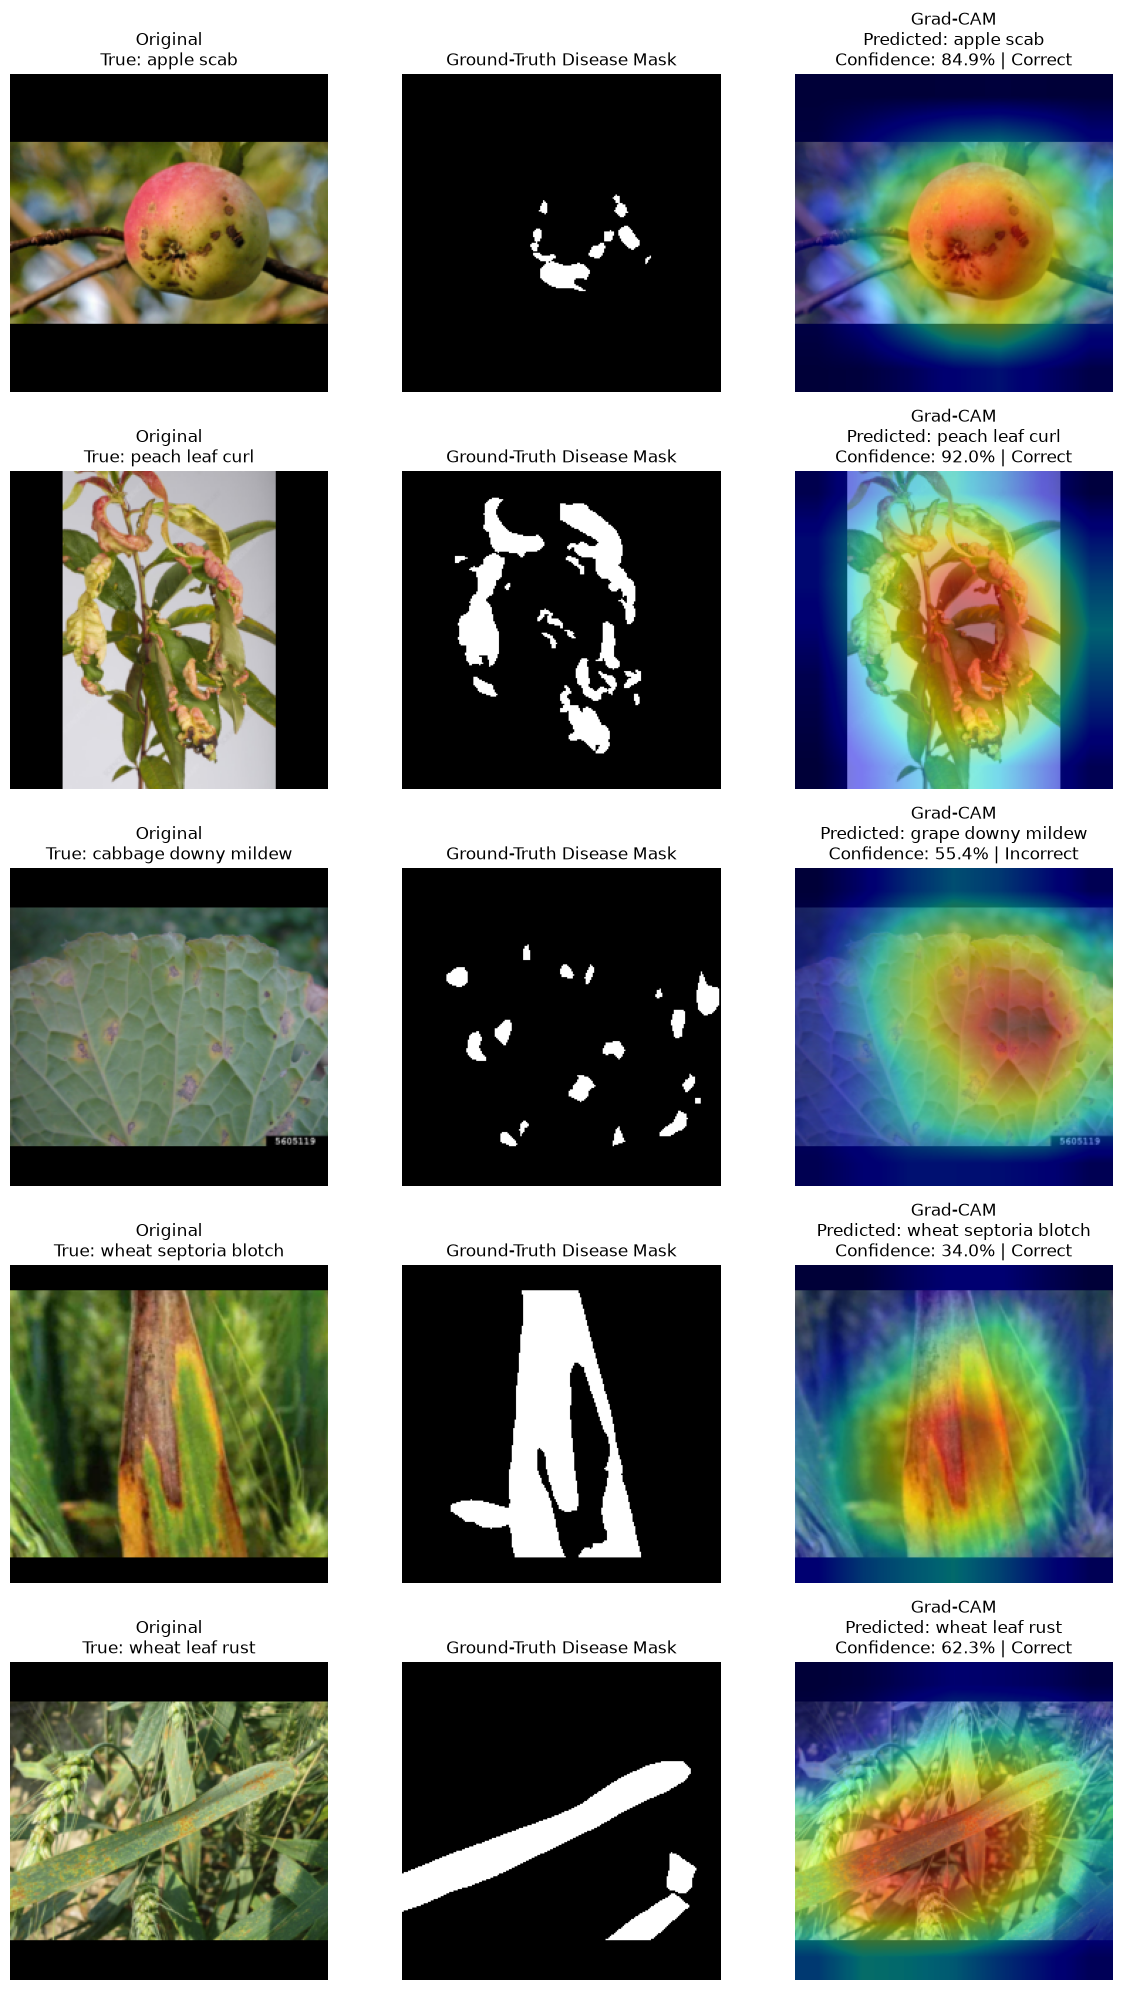

In [24]:
fig, axes = plt.subplots(
    len(gradcam_results),
    3,
    figsize=(12, 4 * len(gradcam_results))
)

for i, result in enumerate(gradcam_results):

    # Apply the same padding used by the classifier
    display_img = ResizeWithPadding((224, 224))(result["image"])
    display_img = np.array(display_img)

    # Original
    axes[i, 0].imshow(display_img)
    axes[i, 0].set_title(
        f"Original\n"
        f"True: {result['true_disease']}"
    )
    axes[i, 0].axis("off")

    # Ground truth mask
    axes[i, 1].imshow(result["mask"], cmap="gray")
    axes[i, 1].set_title("Ground-Truth Disease Mask")
    axes[i, 1].axis("off")

    # Grad-CAM
    axes[i, 2].imshow(display_img)
    axes[i, 2].imshow(
        result["cam"],
        cmap="jet",
        alpha=0.45
    )

    status = "Correct" if result["correct"] else "Incorrect"

    axes[i, 2].set_title(
        f"Grad-CAM\n"
        f"Predicted: {result['predicted_disease']}\n"
        f"Confidence: {result['confidence']:.1%} | {status}"
    )
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

## Grad-CAM Explainability Conclusion

Grad-CAM was applied to the fine-tuned ResNet-18 disease classifier using the final convolutional block (`model.layer4[-1]`) to visualize image regions contributing to disease predictions.

The experiment used test-set images from the cleaned PlantSeg dataset. Grad-CAM heatmaps were generated for the model's predicted disease class and compared qualitatively with the corresponding ground-truth disease masks.

### Qualitative Observations

The Grad-CAM visualizations generally concentrated on plant and leaf regions rather than unrelated background areas. For correctly classified examples such as apple scab, peach leaf curl, wheat septoria blotch, and wheat leaf rust, the strongest activations were located around visually relevant plant regions.

One cabbage downy mildew example was incorrectly classified as grape downy mildew with 55.4% confidence. Despite the incorrect disease classification, the Grad-CAM still concentrated primarily on the affected leaf region. This demonstrates that a prediction error can still have a visually meaningful explanation.

For the zucchini yellow mosaic virus example, 81.17% of the thresholded Grad-CAM region overlapped with the annotated disease mask, while the Grad-CAM covered 32.97% of the total annotated disease region. These values are treated as exploratory explanation-overlap measures rather than formal segmentation metrics because Grad-CAM is a coarse class-discriminative visualization.

### Overall Finding

Grad-CAM provides an interpretable view of where the classifier is focusing when making disease predictions. The results support the explainability component of AgriSense by showing that model attention can be inspected alongside the pixel-level disease localization provided by the segmentation branch.

Grad-CAM is used as a qualitative explanation method and does not establish that highlighted regions are causally responsible for the prediction.

The fine-tuned ResNet-18 remains the primary disease classification model, while the U-Net provides pixel-level disease localization.